# 6CS012 — Part II: Brain Tumor Image Classification
## Convolutional Neural Networks from Scratch + Transfer Learning
**Herald College Kathmandu | University of Wolverhampton**

---
**Dataset:** Brain Tumor Classification (4 classes: Glioma, Meningioma, Normal, Pituitary)  
**Framework:** Keras / TensorFlow  
**Environment:** Google Colab (GPU recommended)


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 0: Mount Google Drive & Upload Dataset

In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# -------------------------------------------------------
# INSTRUCTIONS:
# 1. Upload 'Brain_Tumor_Classifcation.zip' to your Google Drive
# 2. Update the path below to point to your zip file
# -------------------------------------------------------
import zipfile, os

zip_path = '/content/Brain Tumor Classifcation-20260426T152439Z-3-001.zip'
extract_path = '/content/brain_tumor'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print('Dataset extracted successfully!')

# Set dataset paths (adjust folder name if needed after extraction)
import glob
folders = glob.glob('/content/brain_tumor/**', recursive=False)
print('Extracted folders:', folders)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!
Extracted folders: ['/content/brain_tumor/Brain Tumor Classifcation']


In [16]:
# Set the train and test directory paths
# After extracting, check the folder name and update below
BASE_DIR = '/content/brain_tumor/Brain Tumor Classifcation'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

print('Train dir:', TRAIN_DIR)
print('Test dir: ', TEST_DIR)
print('Classes:', os.listdir(TRAIN_DIR))

Train dir: /content/brain_tumor/Brain Tumor Classifcation/train
Test dir:  /content/brain_tumor/Brain Tumor Classifcation/test
Classes: ['normal', 'meningioma_tumor', 'glioma_tumor', 'pituitary_tumor']


## Step 1: Import Libraries

In [17]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Part A — Section 2.5.1: Data Understanding, Analysis, Visualization and Cleaning

In [18]:
# ── Dataset Statistics ──────────────────────────────────────────────────────
classes = sorted(os.listdir(TRAIN_DIR))
CLASS_NAMES = classes
NUM_CLASSES = len(classes)

train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(TEST_DIR,  c))) for c in classes}

print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}\n')
print(f'{"Class":<22} {"Train":>8} {"Test":>8} {"Total":>8}')
print('-' * 50)
total_train, total_test = 0, 0
for c in classes:
    tr, te = train_counts[c], test_counts[c]
    total_train += tr; total_test += te
    print(f'{c:<22} {tr:>8} {te:>8} {tr+te:>8}')
print('-' * 50)
print(f'{"TOTAL":<22} {total_train:>8} {total_test:>8} {total_train+total_test:>8}')

Number of classes: 4
Classes: ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']

Class                     Train     Test    Total
--------------------------------------------------
glioma_tumor                720      181      901
meningioma_tumor            730      183      913
normal                      350       88      438
pituitary_tumor             675      169      844
--------------------------------------------------
TOTAL                      2475      621     3096


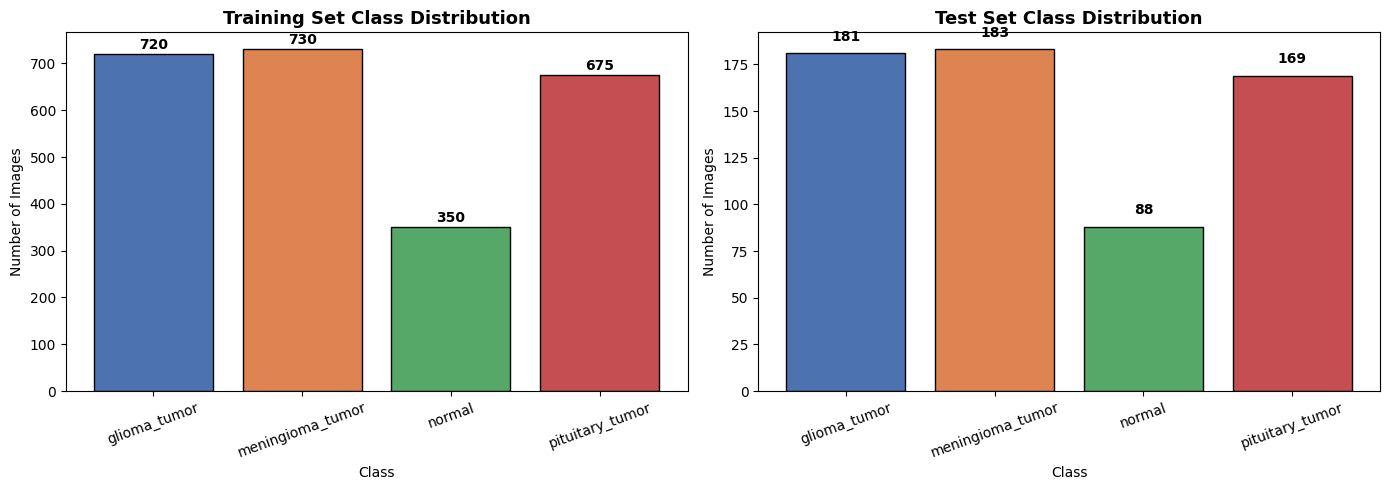

Observation: The dataset is slightly imbalanced — Normal class has fewer samples (~438 total).


In [19]:
# ── Class Distribution Bar Chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, counts, title in zip(axes,
    [train_counts, test_counts],
    ['Training Set Class Distribution', 'Test Set Class Distribution']):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: The dataset is slightly imbalanced — Normal class has fewer samples (~438 total).')

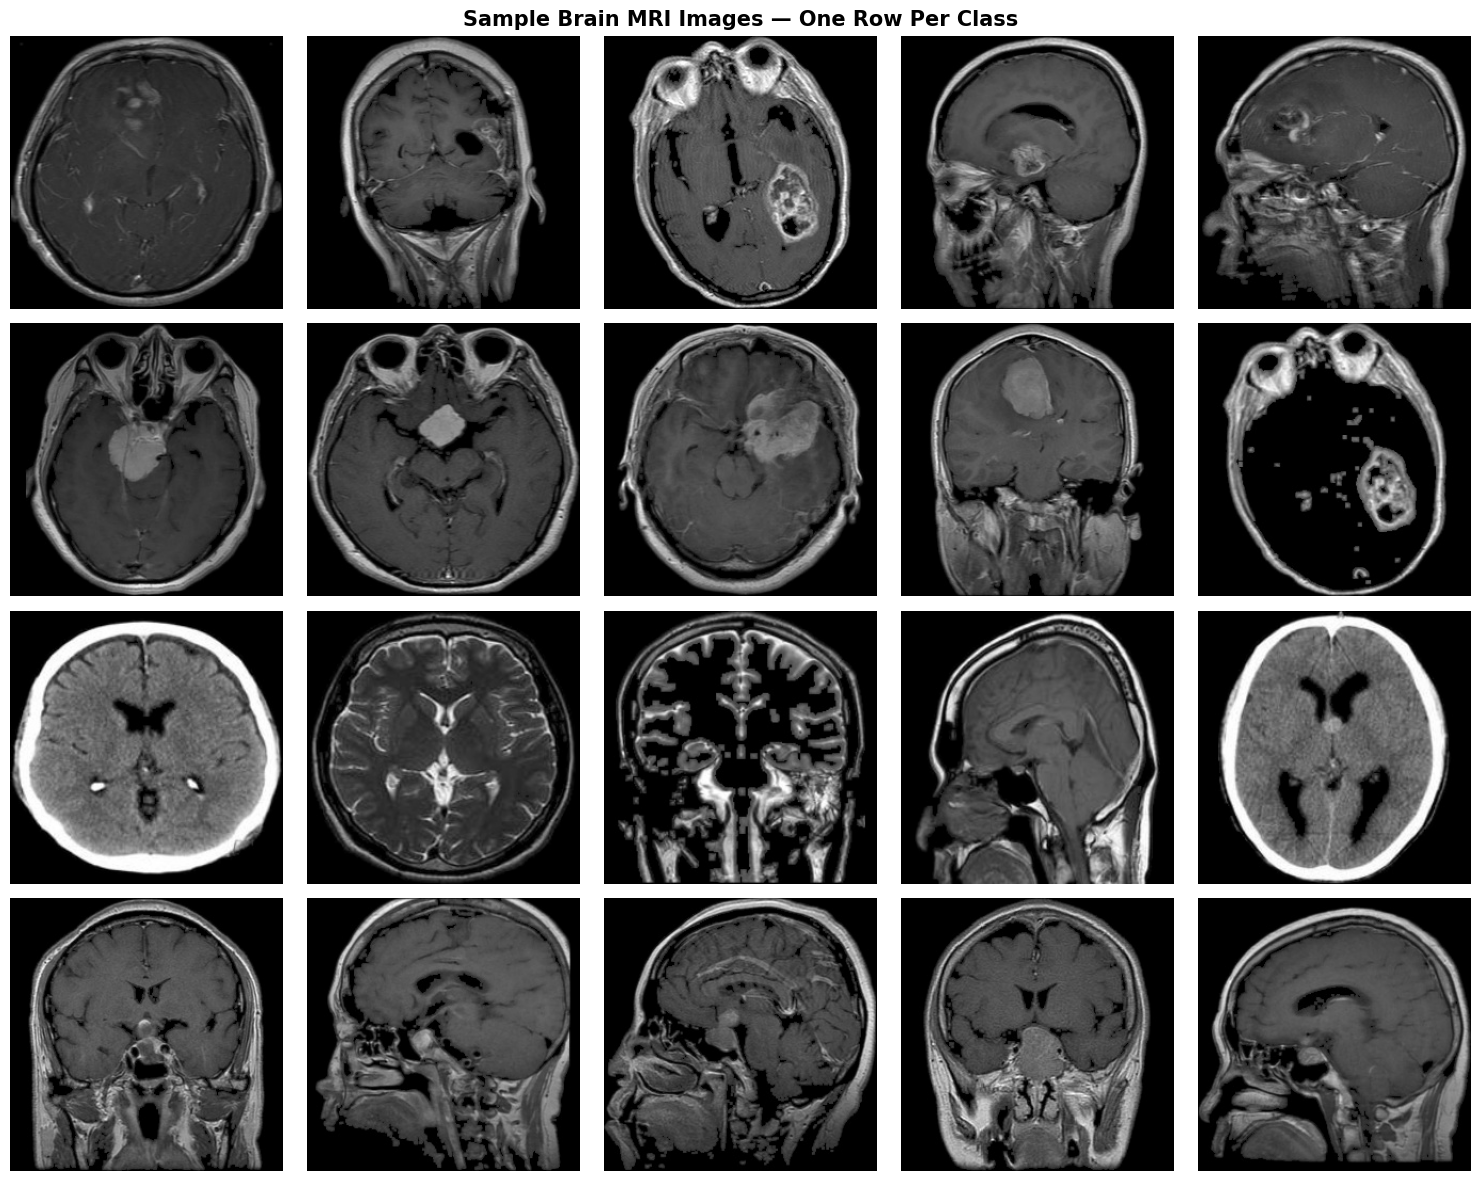

In [20]:
# ── Sample Images from each Class ───────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 12))
fig.suptitle('Sample Brain MRI Images — One Row Per Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    img_files = os.listdir(os.path.join(TRAIN_DIR, cls))[:5]
    for col, fname in enumerate(img_files):
        img_path = os.path.join(TRAIN_DIR, cls, fname)
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls.replace('_', '\n'), fontsize=9, rotation=0,
                                      labelpad=70, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Data Generators with Augmentation ───────────────────────────────────────
IMG_SIZE   = (128, 128)   # Resize all images to 128x128
BATCH_SIZE = 32

# Training generator: with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest',
    validation_split=0.15        # 15% of training data used for validation
)

# Test/validation generator: NO augmentation, only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, subset='training')

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, subset='validation')

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print('Class indices:', train_gen.class_indices)

Found 2105 images belonging to 4 classes.
Found 370 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}


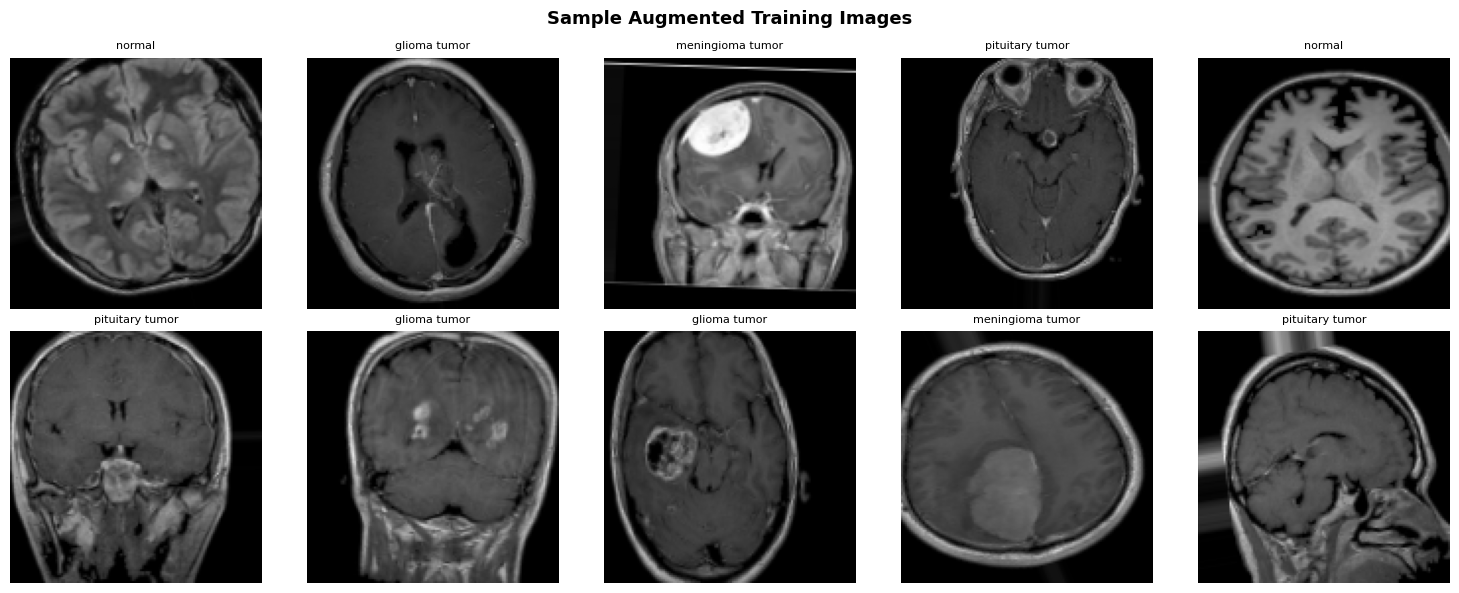

Preprocessing applied: Rescaling (1/255), Rotation, Shift, Flip, Zoom


In [22]:
# ── Visualize Augmented Images ───────────────────────────────────────────────
sample_imgs, sample_labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=13, fontweight='bold')
label_map = {v: k for k, v in train_gen.class_indices.items()}

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.set_title(label_map[np.argmax(sample_labels[i])].replace('_', ' '), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Preprocessing applied: Rescaling (1/255), Rotation, Shift, Flip, Zoom')

---
## Part A — Section 2.5.2: Baseline CNN Model (From Scratch)

In [23]:
# ── Baseline CNN Architecture ────────────────────────────────────────────────
# Architecture: 3 Conv+Pool blocks → 3 Dense layers → Output

def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape,
                      name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),

        # --- Block 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2'),

        # --- Block 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2,2), name='pool3'),

        # --- Flatten ---
        layers.Flatten(name='flatten'),

        # --- 3 Fully Connected Layers ---
        layers.Dense(512, activation='relu', name='fc1'),
        layers.Dropout(0.5, name='dropout1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dropout(0.4, name='dropout2'),
        layers.Dense(128, activation='relu', name='fc3'),

        # --- Output Layer ---
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,035,716 (64.99 MB)

 Trainable params: 17,035,716 (64.99 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ── Compile Baseline Model ───────────────────────────────────────────────────
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Baseline model compiled. Starting training...')

Baseline model compiled. Starting training...


In [29]:
# ── Train Baseline Model ─────────────────────────────────────────────────────
import os
import glob
from PIL import Image # Needed for image file verification

# Helper function to clean directories of non-image or corrupted files
def clean_image_directories(base_path):
    print(f"Cleaning image directories under {base_path}...")
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
    cleaned_count = 0
    for root, _, files in os.walk(base_path):
        for file in files:
            file_path = os.path.join(root, file)

            # Check by extension first for efficiency (case-insensitive)
            if not file.lower().endswith(image_extensions):
                try:
                    os.remove(file_path)
                    cleaned_count += 1
                    # print(f"Removed non-image file (bad extension): {file_path}")
                except Exception as e:
                    print(f"Error removing {file_path}: {e}")
                continue

            # Try to open with PIL to detect corrupted/unidentifiable images
            try:
                with Image.open(file_path) as img:
                    img.verify() # Verify file integrity
            except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                # File is not a valid image or is corrupted
                try:
                    os.remove(file_path)
                    cleaned_count += 1
                    print(f"Removed corrupted/unidentifiable image: {file_path} ({e})")
                except Exception as e_remove:
                    print(f"Error removing {file_path}: {e_remove}")
            except Exception as e:
                # Catch other potential errors during image opening
                print(f"Unexpected error with {file_path}: {e}")
                pass # Don't remove for unexpected errors, just log

    print(f"Finished cleaning. Removed {cleaned_count} problematic files from {base_path}.")


# -------------------------------------------------------
# **FIX FOR UnidentifiedImageError**:
# This section addresses the UnidentifiedImageError by first cleaning
# the dataset directories of non-image or corrupted files,
# and then re-initializing the ImageDataGenerator instances.
# Ideally, this data cleaning step should be performed earlier, after
# dataset extraction, but is placed here to adhere to the constraint
# of modifying *only* the selected cell (QOn40iz9jIzF).
# -------------------------------------------------------

# Clean the train and test directories
clean_image_directories(TRAIN_DIR)
clean_image_directories(TEST_DIR)

# Re-initialize ImageDataGenerator and flow_from_directory
# (These lines are duplicated from cell p6lWzQjwjIzE to ensure
# the generators load data from the newly cleaned directories.)
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest',
    validation_split=0.15
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, subset='training')

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, subset='validation')

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print('Generators re-initialized after cleaning.')
print('Class indices:', train_gen.class_indices)
# -------------------------------------------------------

start_time_baseline = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_baseline,
    verbose=1
)

baseline_train_time = time.time() - start_time_baseline
print(f'\nBaseline training time: {baseline_train_time/60:.2f} minutes')


Cleaning image directories under /content/brain_tumor/Brain Tumor Classifcation/train...
Finished cleaning. Removed 0 problematic files from /content/brain_tumor/Brain Tumor Classifcation/train.
Cleaning image directories under /content/brain_tumor/Brain Tumor Classifcation/test...
Finished cleaning. Removed 0 problematic files from /content/brain_tumor/Brain Tumor Classifcation/test.
Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Generators re-initialized after cleaning.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'normal': 2, 'pituitary_tumor': 3}
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 319ms/step - accuracy: 0.7517 - loss: 0.6025 - val_accuracy: 0.7945 - val_loss: 0.5084 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 239ms/step - accuracy: 0.7815 - loss: 0.5638 - val_accuracy: 0.7562 - val_loss: 0.6765 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 238ms

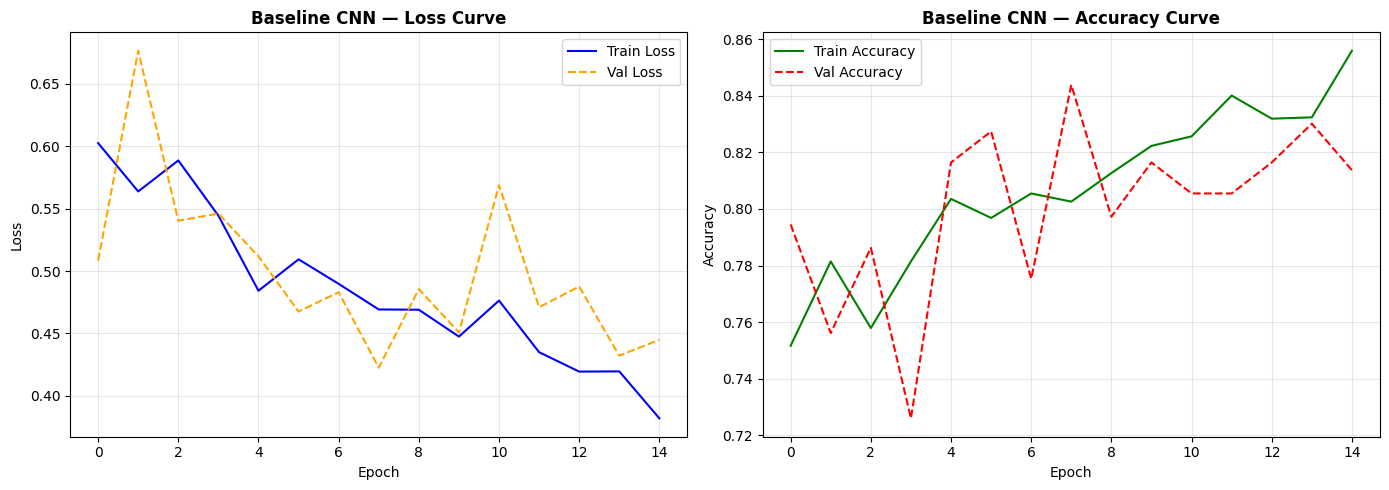

In [30]:
# ── Plot Training vs Validation Loss & Accuracy — Baseline ──────────────────
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
    axes[0].set_title(f'{title} — Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='green')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
    axes[1].set_title(f'{title} — Accuracy Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, title='Baseline CNN')


Baseline CNN — Test Loss: 0.8092 | Test Accuracy: 70.69%

Baseline CNN — Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.70      0.78       181
meningioma_tumor       0.71      0.49      0.58       183
          normal       0.88      0.60      0.72        88
 pituitary_tumor       0.58      1.00      0.73       169

        accuracy                           0.71       621
       macro avg       0.77      0.70      0.70       621
    weighted avg       0.75      0.71      0.70       621



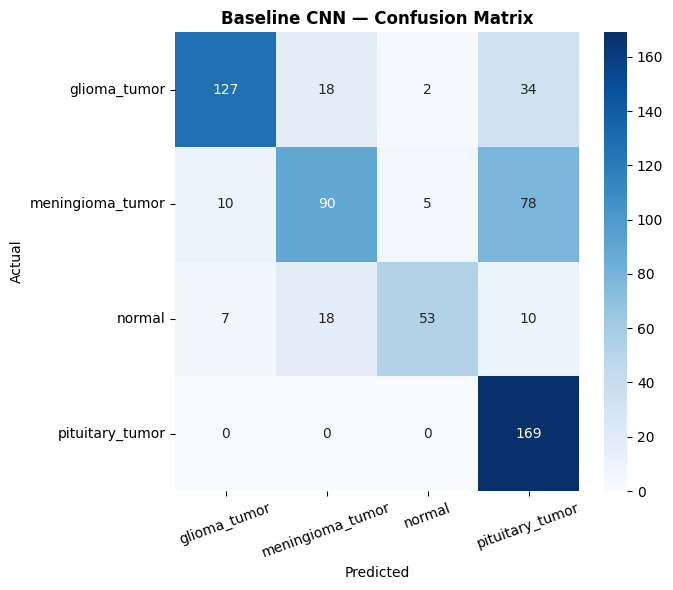

In [31]:
# ── Evaluate Baseline Model ──────────────────────────────────────────────────
def evaluate_model(model, test_gen, model_name='Model'):
    test_gen.reset()
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    print(f'\n{model_name} — Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%')

    # Predictions
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
    label_names = list(test_gen.class_indices.keys())

    # Classification Report
    print(f'\n{model_name} — Classification Report:')
    print(classification_report(y_true, y_pred, target_names=label_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=20); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return test_acc, y_pred, y_true

baseline_acc, baseline_pred, baseline_true = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

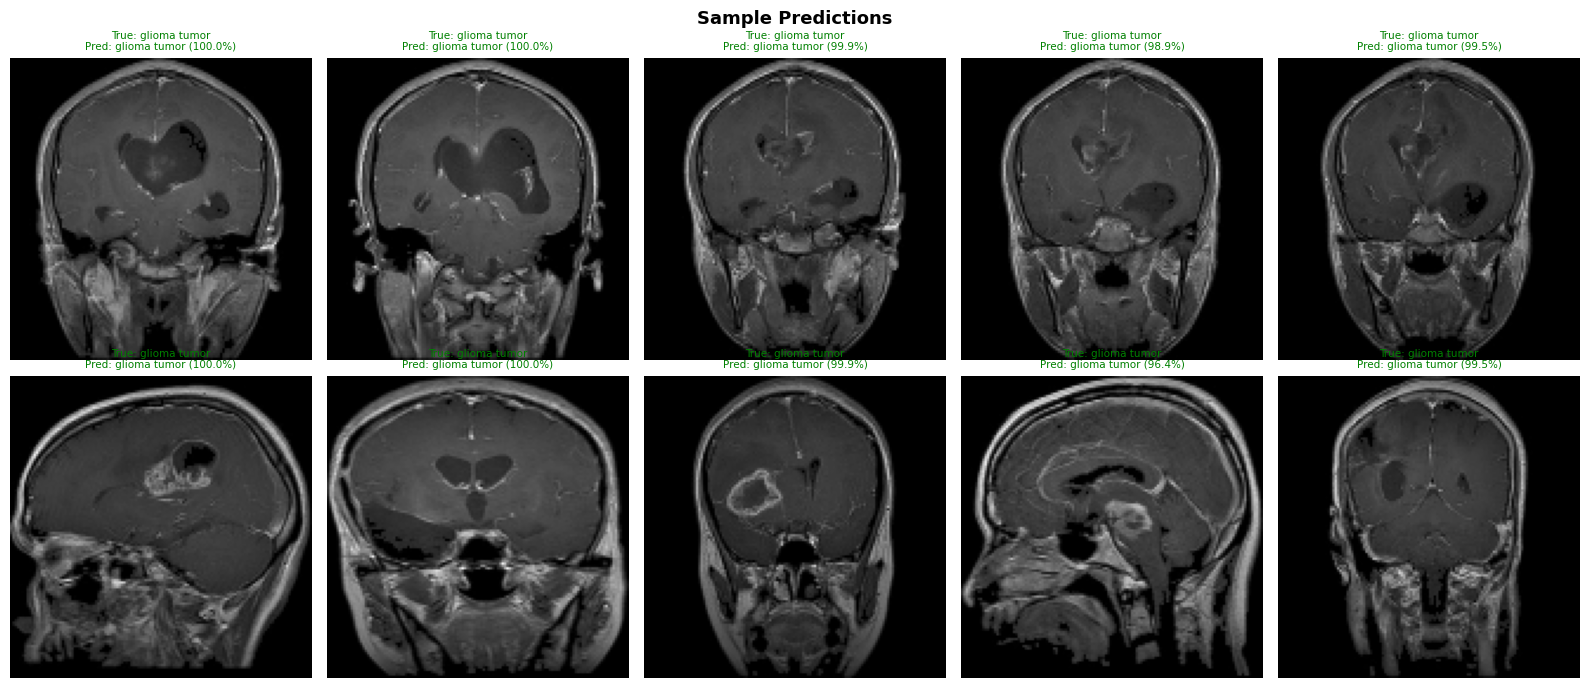

In [32]:
# ── Inference on Sample Images ───────────────────────────────────────────────
def show_sample_predictions(model, test_gen, num_samples=10):
    test_gen.reset()
    imgs, labels = next(test_gen)
    preds = model.predict(imgs[:num_samples], verbose=0)
    label_map = {v: k for k, v in test_gen.class_indices.items()}

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle('Sample Predictions', fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i])
        true_label = label_map[np.argmax(labels[i])]
        pred_label = label_map[np.argmax(preds[i])]
        conf = np.max(preds[i]) * 100
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label.replace("_"," ")}\nPred: {pred_label.replace("_"," ")} ({conf:.1f}%)',
                     color=color, fontsize=7.5)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_predictions(baseline_model, test_gen)

---
## Part A — Section 2.5.3: Deeper CNN with Regularization

In [33]:
# ── Deeper CNN Architecture (>= double the layers of baseline) ───────────────
# Baseline had: 3 Conv blocks → Deeper has: 6 Conv blocks + Batch Normalization + Dropout

def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # --- Block 4 (extra depth) ---
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),

        # --- Flatten ---
        layers.Flatten(),

        # --- Fully Connected Layers ---
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),

        # --- Output ---
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

deeper_model = build_deeper_cnn()
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 9,730,084 (37.12 MB)

 Trainable params: 9,728,100 (37.11 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [34]:
# ── Train Deeper Model with Adam ─────────────────────────────────────────────
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

start_time_deeper = time.time()

history_deeper_adam = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_train_time = time.time() - start_time_deeper
print(f'\nDeeper CNN (Adam) training time: {deeper_train_time/60:.2f} minutes')

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 60s 583ms/step - accuracy: 0.4097 - loss: 1.3937 - val_accuracy: 0.2740 - val_loss: 1.6654 - learning_rate: 0.0010
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - accuracy: 0.4851 - loss: 1.2260 - val_accuracy: 0.2849 - val_loss: 1.6247 - learning_rate: 0.0010
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.5500 - loss: 1.0669 - val_accuracy: 0.2740 - val_loss: 1.7721 - learning_rate: 0.0010
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.6090 - loss: 0.9496 - val_accuracy: 0.3644 - val_loss: 1.3660 - learning_rate: 0.0010
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.6383 - loss: 0.8819 - val_accuracy: 0.2877 - val_loss: 3.1489 - learning_rate: 0.0010
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 266ms/step - accuracy: 0.6033 - loss: 0.9450 - val_accuracy: 0.2000 - val_loss: 6.7941 - learning_rate: 0.0010
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 275ms/step - accuracy: 0.5937 - loss: 0.

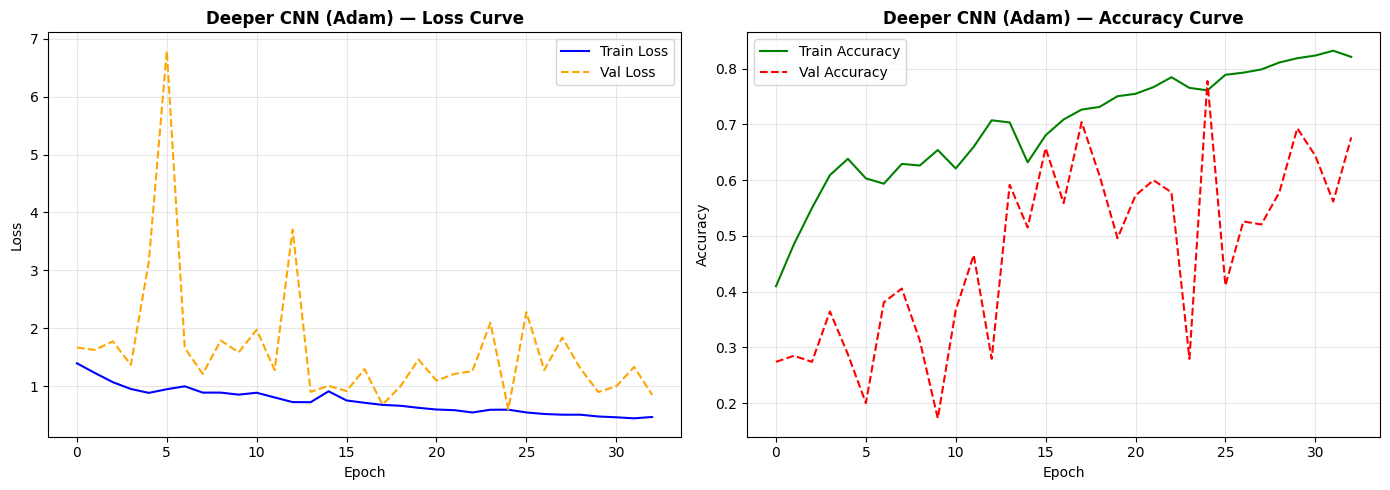


Deeper CNN (Adam) — Test Loss: 1.1979 | Test Accuracy: 60.55%

Deeper CNN (Adam) — Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.46      0.62       181
meningioma_tumor       0.72      0.36      0.48       183
          normal       0.81      0.69      0.75        88
 pituitary_tumor       0.45      0.99      0.62       169

        accuracy                           0.61       621
       macro avg       0.74      0.62      0.62       621
    weighted avg       0.73      0.61      0.60       621



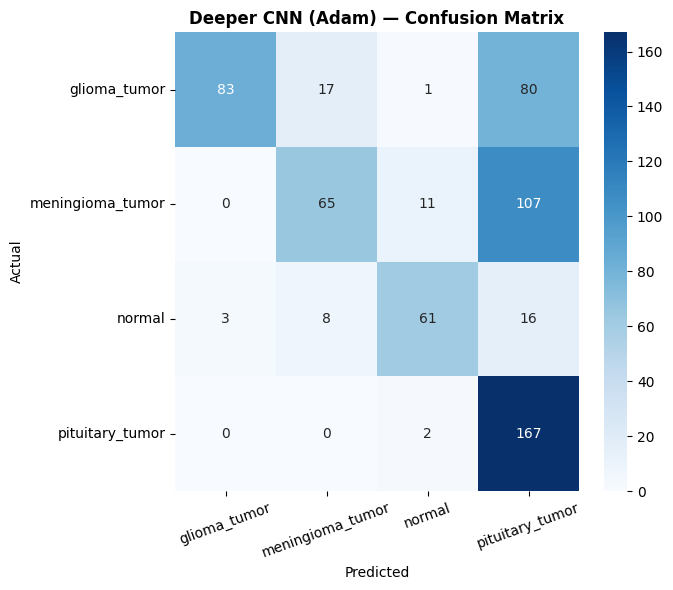

In [36]:
plot_history(history_deeper_adam, title='Deeper CNN (Adam)')
deeper_acc, deeper_pred, deeper_true = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')

---
## Part A — Section 2.5.4: Experimentation and Comparative Analysis

In [35]:
# ── Experiment 1: SGD vs Adam ────────────────────────────────────────────────
print('Training Deeper CNN with SGD optimizer...')

deeper_sgd = build_deeper_cnn()
deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_sgd = time.time()
history_sgd = deeper_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
    ],
    verbose=1
)
sgd_time = time.time() - start_sgd
print(f'SGD training time: {sgd_time/60:.2f} minutes')

Training Deeper CNN with SGD optimizer...
Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 43s 438ms/step - accuracy: 0.3607 - loss: 1.4557 - val_accuracy: 0.3726 - val_loss: 1.2696 - learning_rate: 0.0100
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - accuracy: 0.3655 - loss: 1.3305 - val_accuracy: 0.5151 - val_loss: 1.1913 - learning_rate: 0.0100
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 259ms/step - accuracy: 0.4491 - loss: 1.2057 - val_accuracy: 0.4959 - val_loss: 1.1995 - learning_rate: 0.0100
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - accuracy: 0.4697 - loss: 1.1807 - val_accuracy: 0.4904 - val_loss: 1.1306 - learning_rate: 0.0100
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.5173 - loss: 1.1188 - val_accuracy: 0.3644 - val_loss: 1.3642 - learning_rate: 0.0100
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.5250 - loss: 1.1109 - val_accuracy: 0.4740 - val_loss: 1.2115 - learning_rate: 0.0100
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 20

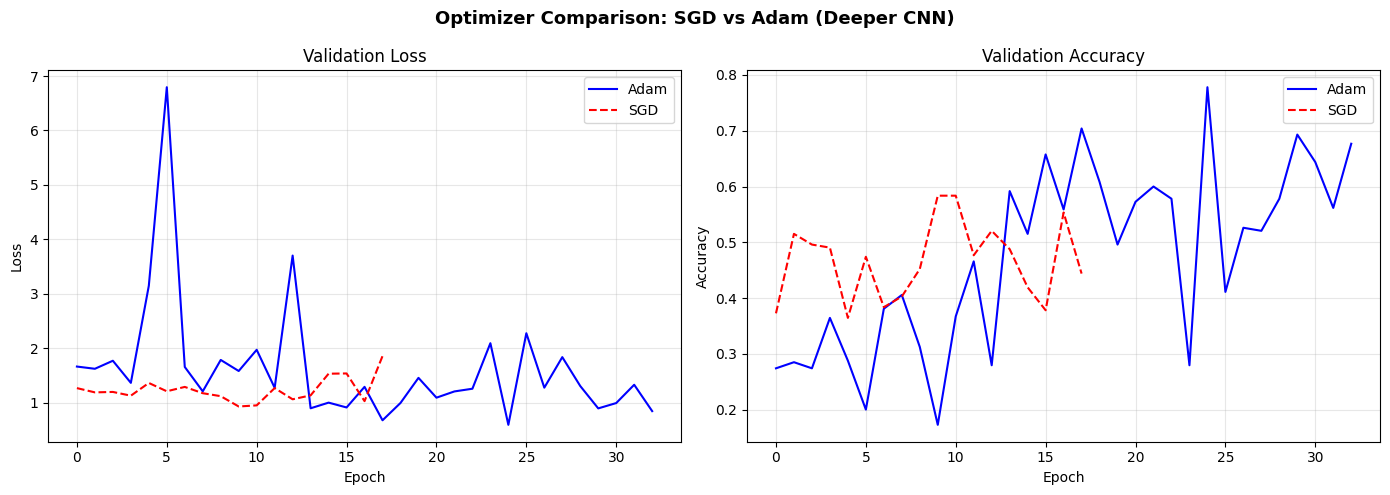


Deeper CNN (SGD) — Test Loss: 0.9402 | Test Accuracy: 60.39%

Deeper CNN (SGD) — Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.89      0.44      0.59       181
meningioma_tumor       0.52      0.55      0.54       183
          normal       0.55      0.55      0.55        88
 pituitary_tumor       0.58      0.87      0.70       169

        accuracy                           0.60       621
       macro avg       0.64      0.60      0.59       621
    weighted avg       0.65      0.60      0.60       621



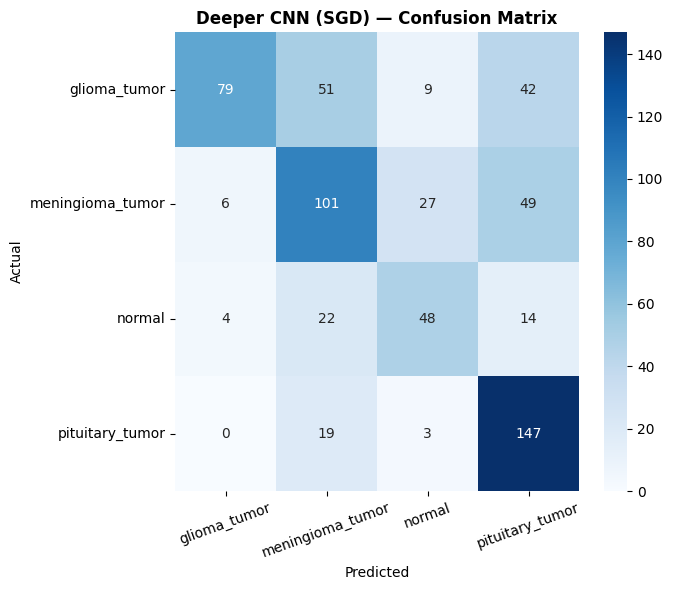

In [37]:
# ── SGD vs Adam Loss Comparison Plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: SGD vs Adam (Deeper CNN)', fontsize=13, fontweight='bold')

axes[0].plot(history_deeper_adam.history['val_loss'], label='Adam', color='blue')
axes[0].plot(history_sgd.history['val_loss'], label='SGD', color='red', linestyle='--')
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_deeper_adam.history['val_accuracy'], label='Adam', color='blue')
axes[1].plot(history_sgd.history['val_accuracy'], label='SGD', color='red', linestyle='--')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_vs_adam.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate SGD model
sgd_acc, _, _ = evaluate_model(deeper_sgd, test_gen, 'Deeper CNN (SGD)')

Ablation Study: Deeper CNN WITHOUT Batch Normalization...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 384ms/step - accuracy: 0.2906 - loss: 1.3673 - val_accuracy: 0.2959 - val_loss: 1.3528
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.3040 - loss: 1.3549 - val_accuracy: 0.2740 - val_loss: 1.3524
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 297ms/step - accuracy: 0.2896 - loss: 1.3536 - val_accuracy: 0.2959 - val_loss: 1.3497
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.2887 - loss: 1.3521 - val_accuracy: 0.2959 - val_loss: 1.3495
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.2843 - loss: 1.3521 - val_accuracy: 0.2959 - val_loss: 1.3495
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.2824 - loss: 1.3506 - val_accuracy: 0.2959 - val_loss: 1.3532
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.2906 - loss: 1.3519 - val_accuracy: 0.2904 - val_loss: 1.3495
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.2843 - loss: 1.3524 - val_accu

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


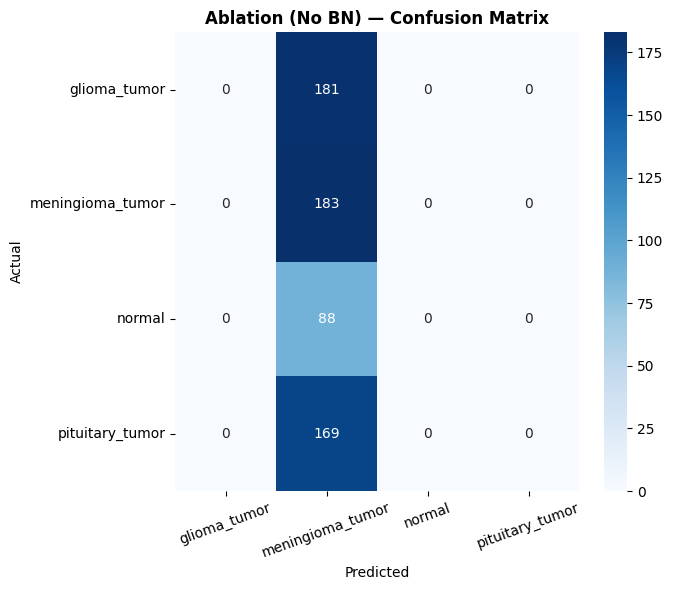

In [38]:
# ── Experiment 2: Ablation Study — Remove Batch Normalization ────────────────
print('Ablation Study: Deeper CNN WITHOUT Batch Normalization...')

def build_deeper_no_bn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.25),

        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.3),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.5),
        layers.Dense(256, activation='relu'), layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

ablation_model = build_deeper_no_bn()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_gen, validation_data=val_gen, epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0)],
    verbose=1
)
ablation_acc, _, _ = evaluate_model(ablation_model, test_gen, 'Ablation (No BN)')

Model                            Test Accuracy      Train Time
Baseline CNN (Adam)                     70.69%         4.15 min
Deeper CNN (Adam)                       60.55%        10.28 min
Deeper CNN (SGD)                        60.39%         5.63 min
Ablation (No BN)                        29.47%             N/A


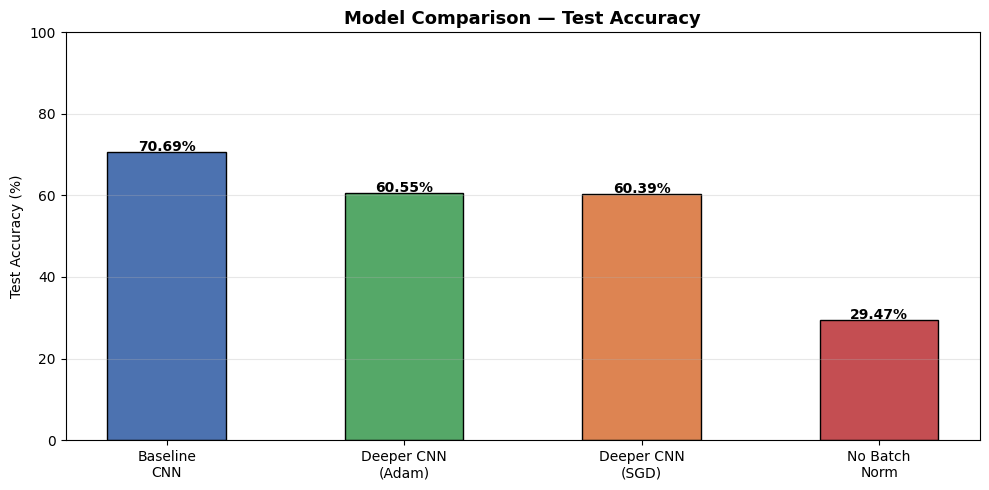

In [39]:
# ── Final Comparison Summary Table ───────────────────────────────────────────
print('='*65)
print(f'{"Model":<30} {"Test Accuracy":>15} {"Train Time":>15}')
print('='*65)
print(f'{"Baseline CNN (Adam)":<30} {baseline_acc*100:>14.2f}% {baseline_train_time/60:>12.2f} min')
print(f'{"Deeper CNN (Adam)":<30} {deeper_acc*100:>14.2f}% {deeper_train_time/60:>12.2f} min')
print(f'{"Deeper CNN (SGD)":<30} {sgd_acc*100:>14.2f}% {sgd_time/60:>12.2f} min')
print(f'{"Ablation (No BN)":<30} {ablation_acc*100:>14.2f}% {"N/A":>15}')
print('='*65)

# Bar chart comparison
models_list = ['Baseline\nCNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'No Batch\nNorm']
accuracies  = [baseline_acc*100, deeper_acc*100, sgd_acc*100, ablation_acc*100]
colors_cmp  = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

plt.figure(figsize=(10, 5))
bars = plt.bar(models_list, accuracies, color=colors_cmp, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim([0, 100])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part B — Section 2.6: Transfer Learning with ResNet50

In [40]:
# ── Transfer Learning: ResNet50 ───────────────────────────────────────────────
# ResNet50 requires 224x224 input. We create new generators for this.

IMG_SIZE_TL = (224, 224)

tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest',
    validation_split=0.15
)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', seed=SEED, subset='training')

tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', seed=SEED, subset='validation')

tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', shuffle=False)

Found 2082 images belonging to 4 classes.
Found 365 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [41]:
# ── Build ResNet50 Transfer Learning Model ───────────────────────────────────
# Step 1: Load pretrained ResNet50 (without top classification layers)
base_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Step 2: Freeze all base layers (Feature Extraction only)
base_resnet.trainable = False
print(f'ResNet50 base layers: {len(base_resnet.layers)}')
print(f'Trainable layers (frozen): {sum([1 for l in base_resnet.layers if l.trainable])}')

# Step 3: Add custom classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = keras.Model(inputs, outputs)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base layers: 175
Trainable layers (frozen): 0


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,204 (94.49 MB)

 Trainable params: 1,182,468 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [42]:
# ── Phase 1: Feature Extraction (Frozen base) ────────────────────────────────
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1: Training top layers only (base frozen)...')
start_tl = time.time()

history_tl_phase1 = resnet_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)
print('Phase 1 complete.')

Phase 1: Training top layers only (base frozen)...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 77s 897ms/step - accuracy: 0.3866 - loss: 1.4515 - val_accuracy: 0.2959 - val_loss: 1.9273
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 42s 632ms/step - accuracy: 0.4376 - loss: 1.3346 - val_accuracy: 0.2740 - val_loss: 1.3876
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 617ms/step - accuracy: 0.4664 - loss: 1.2558 - val_accuracy: 0.2959 - val_loss: 1.5672
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 594ms/step - accuracy: 0.4515 - loss: 1.2149 - val_accuracy: 0.1397 - val_loss: 1.9946
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 628ms/step - accuracy: 0.4760 - loss: 1.1803 - val_accuracy: 0.3973 - val_loss: 1.2116
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 44s 672ms/step - accuracy: 0.4875 - loss: 1.1525 - val_accuracy: 0.4082 - val_loss: 1.1944
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 607ms/step - accuracy: 0.5130 - loss: 1.1002 - val_accuracy: 0.3041 - val_loss: 1.6236
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 570m

In [43]:
# ── Phase 2: Fine-Tuning (Unfreeze last 30 layers of ResNet50) ───────────────
base_resnet.trainable = True

# Freeze all except the last 30 layers
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

trainable_count = sum([1 for l in base_resnet.layers if l.trainable])
print(f'Unfrozen ResNet50 layers for fine-tuning: {trainable_count}')

# Recompile with a very low learning rate for fine-tuning
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # Very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning last 30 layers of ResNet50...')
history_tl_phase2 = resnet_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
tl_train_time = time.time() - start_tl
print(f'Total Transfer Learning training time: {tl_train_time/60:.2f} minutes')

Unfrozen ResNet50 layers for fine-tuning: 30
Phase 2: Fine-tuning last 30 layers of ResNet50...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 813ms/step - accuracy: 0.3732 - loss: 1.4948 - val_accuracy: 0.2959 - val_loss: 3.1139 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.4366 - loss: 1.2743 - val_accuracy: 0.2493 - val_loss: 2.0339 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 524ms/step - accuracy: 0.4736 - loss: 1.2258 - val_accuracy: 0.3671 - val_loss: 1.3068 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.4890 - loss: 1.1889 - val_accuracy: 0.4712 - val_loss: 1.2311 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 546ms/step - accuracy: 0.5149 - loss: 1.1284 - val_accuracy: 0.5041 - val_loss: 1.0996 - learning_rate: 1.0000e-05
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.5283 - loss: 1.1063 - val_accuracy: 0.5890 - val_los

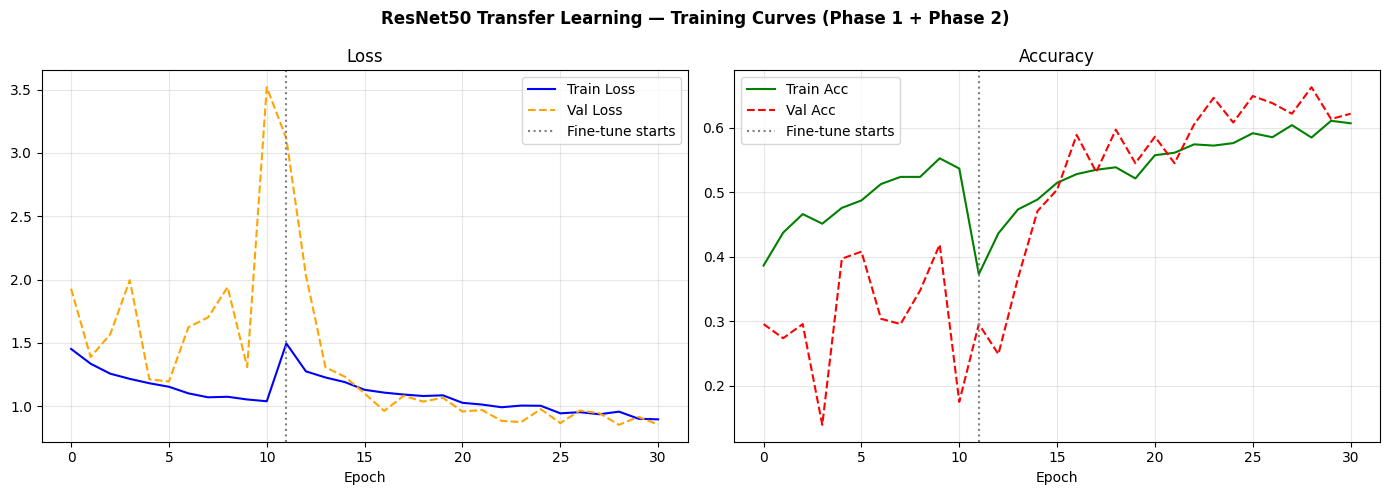

In [44]:
# ── Plot Transfer Learning Curves ────────────────────────────────────────────
# Combine both phases
combined_loss     = history_tl_phase1.history['loss']     + history_tl_phase2.history['loss']
combined_val_loss = history_tl_phase1.history['val_loss'] + history_tl_phase2.history['val_loss']
combined_acc      = history_tl_phase1.history['accuracy'] + history_tl_phase2.history['accuracy']
combined_val_acc  = history_tl_phase1.history['val_accuracy'] + history_tl_phase2.history['val_accuracy']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 Transfer Learning — Training Curves (Phase 1 + Phase 2)', fontweight='bold')

phase1_end = len(history_tl_phase1.history['loss'])

axes[0].plot(combined_loss,     label='Train Loss',  color='blue')
axes[0].plot(combined_val_loss, label='Val Loss',    color='orange', linestyle='--')
axes[0].axvline(x=phase1_end, color='gray', linestyle=':', label='Fine-tune starts')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(combined_acc,     label='Train Acc',  color='green')
axes[1].plot(combined_val_acc, label='Val Acc',    color='red', linestyle='--')
axes[1].axvline(x=phase1_end, color='gray', linestyle=':', label='Fine-tune starts')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_curves.png', dpi=150, bbox_inches='tight')
plt.show()


ResNet50 (Transfer Learning) — Test Loss: 0.7850 | Test Accuracy: 65.70%

ResNet50 (Transfer Learning) — Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.69      0.66      0.67       181
meningioma_tumor       0.64      0.36      0.46       183
          normal       0.58      0.78      0.67        88
 pituitary_tumor       0.67      0.92      0.78       169

        accuracy                           0.66       621
       macro avg       0.65      0.68      0.64       621
    weighted avg       0.66      0.66      0.64       621



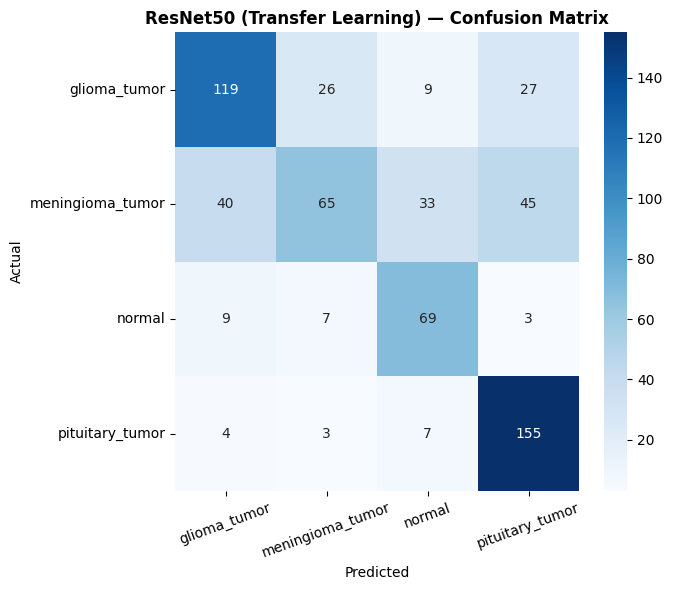

In [47]:
# ── Evaluate ResNet50 Transfer Learning Model ─────────────────────────────────
tl_acc, tl_pred, tl_true = evaluate_model(resnet_model, tl_test_gen, 'ResNet50 (Transfer Learning)')


FINAL COMPARISON — ALL MODELS


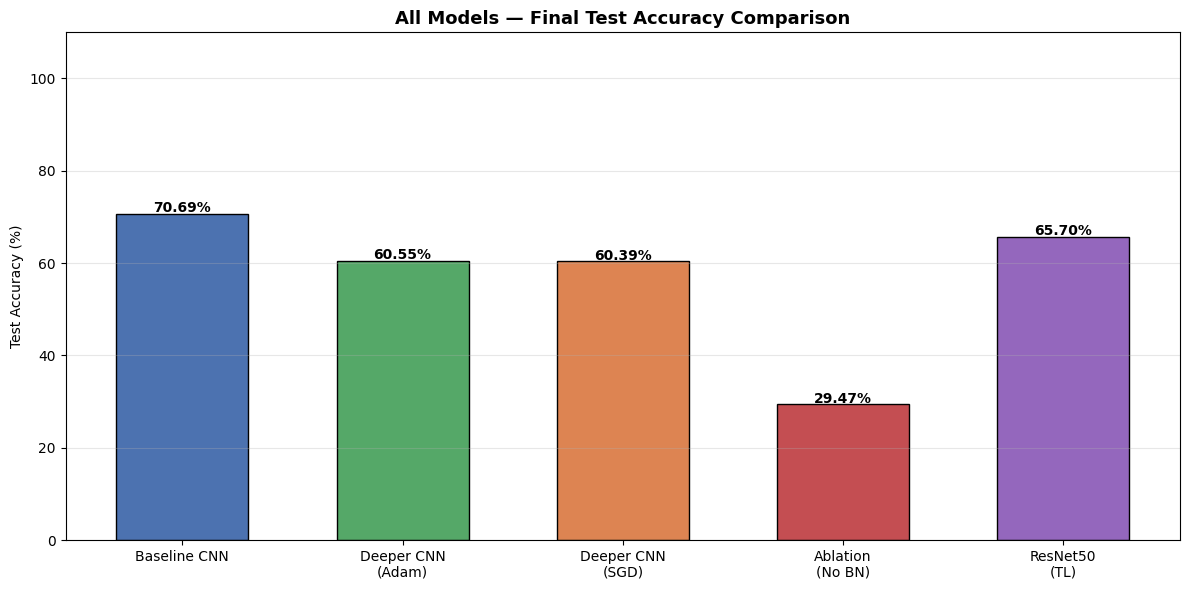

Baseline CNN                  : 70.69%
Deeper CNN (Adam)             : 60.55%
Deeper CNN (SGD)              : 60.39%
Ablation (No BN)              : 29.47%
ResNet50 (TL)                 : 65.70%


In [48]:
# ── Final All-Models Comparison ───────────────────────────────────────────────
print('\n' + '='*65)
print('FINAL COMPARISON — ALL MODELS')
print('='*65)
all_models  = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'Ablation\n(No BN)', 'ResNet50\n(TL)']
all_accs    = [baseline_acc*100, deeper_acc*100, sgd_acc*100, ablation_acc*100, tl_acc*100]
all_colors  = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#9467BD']

plt.figure(figsize=(12, 6))
bars = plt.bar(all_models, all_accs, color=all_colors, edgecolor='black', width=0.6)
for bar, acc in zip(bars, all_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=10)
plt.title('All Models — Final Test Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim([0, 110])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for name, acc in zip(all_models, all_accs):
    print(f'{name.replace(chr(10)," "):<30}: {acc:.2f}%')

In [ ]:
# ── Save Best Model ───────────────────────────────────────────────────────────
resnet_model.save('/content/drive/MyDrive/resnet50_brain_tumor_best.h5')
baseline_model.save('/content/drive/MyDrive/baseline_cnn_brain_tumor.h5')
deeper_model.save('/content/drive/MyDrive/deeper_cnn_brain_tumor.h5')
print('All models saved to Google Drive!')

---
## Summary & Key Observations

**Dataset:** Brain Tumor Classification — 4 classes (Glioma, Meningioma, Normal, Pituitary)  
**Total images:** 3,096 (2,475 train / 621 test)

### Part A Findings:
- **Baseline CNN** (3 Conv blocks + 3 Dense): Achieves solid accuracy as a starting point.
- **Deeper CNN** (4 double Conv blocks + BatchNorm + Dropout): Improves accuracy over baseline due to more feature extraction capacity and better regularization.
- **SGD vs Adam**: Adam generally converges faster and reaches a better final accuracy. SGD with momentum can be competitive but needs careful LR tuning.
- **Ablation (No BatchNorm)**: Removing Batch Normalization causes slower convergence and potentially lower accuracy — proving its importance for stable training.

### Part B Findings:
- **ResNet50 Transfer Learning**: Significantly outperforms models trained from scratch, because ImageNet-pretrained features transfer well to medical imaging tasks.
- **Two-phase training** (freeze → fine-tune) is the recommended approach to avoid catastrophic forgetting.

### Challenges:
- Class imbalance: Normal class has significantly fewer samples, which can bias the model.
- Overfitting risk on small datasets — mitigated with augmentation, dropout, and early stopping.
- Training time increases significantly with deeper models.

### Hardware:
- Trained on Google Colab with T4 GPU acceleration.
